In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.dates as mdates
import numpy as np

import intake

import sys
sys.path.append("/work/mh1498/m301248/TCO_data/COARE-algorithm/Python/COARE3.5/") 

import metpy

import meteo

In [3]:
%load_ext autoreload
%autoreload 2

Diregarding intra-seasonal advection, the mean moisture profile is simply set by th balance between boundary layer top and surface fluxes.
$$ q_\mathrm{bl} = \frac{V_\mathrm{sfc} q_\mathrm{sfc} + E q_{h^+}}{V_\mathrm{sfc} + E}$$

here $V_\mathrm{sfc}$ and $E$ must have dimensions of mass fluxes ($\rho C\cdot U$, with units $g~m^{-2}~s^{-1}$)

then at the surface

$$ W_\mathrm{sfc} \approx \frac{q_\mathrm{bl}}{q_\mathrm{sfc}}  = \frac{V_\mathrm{sfc} + E \frac{q_{h^+}}{q_\mathrm{sfc}} }{V_\mathrm{sfc} + E} = \frac{V_\mathrm{sfc} + \chi \cdot E}{V_\mathrm{sfc} + E} $$

from this, I can rearrange the terms to estimate values for the vertical mass transport needed to attain such surface relative humidity $W_\mathrm{sfc}$

$$ E = \frac{\left( 1 - W_\mathrm{sfc} \right) \cdot V_\mathrm{sfc}}{W - \chi} $$

From the radiosoundings, $W_\mathrm{sfc} = 0.75$ .

Far reaching idea: use computed $E$ in bulk equation from $\theta$


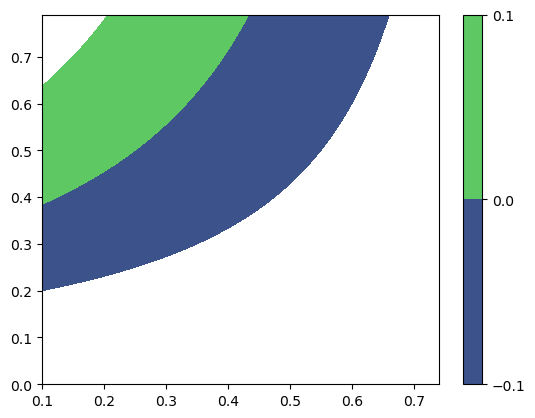

In [34]:
import numpy as np

W = 0.75

chi = np.arange(0.1,W-0.005,0.01)
alpha = np.arange(0, 0.8, 0.01)
 

CHI, ALPHA = np.meshgrid(chi, alpha)

f = W - (1+CHI*ALPHA)/(1+ALPHA)

plt.contourf(CHI, ALPHA, f, levels=[-0.1, 0, 0.1])
plt.colorbar()


# plt.plot(chi, (W-1)/(chi-W))


plt.show()

### set global parameters

In [4]:
## what height is entrained air from?
entrainment_levels = slice(700, 1000)    # m

## what is the reference layer to compute mixed layer AVERAGED quantities?
mixed_avg_levels   = slice(200, 500)

## what height does convective downdrafts come from?
downdraft_levels_eu = slice(750, 1000)
downdraft_levels_or = slice(1000, 1500)


Rd = 287.
cp = 1004. # j / kg K
Lv = 2.5e6 # J/kg
g = 9.81   # m/s2

#### load profiles

In [5]:
min_hgt = 40.

level2_path = "/work/mh1498/m301248/TCO_data/eurec4a_profiles_level2/EUREC4A_BCO_Vaisala-RS_L2_v3.0.0.nc"
ds_eureca = xr.open_dataset(level2_path)
ds_eureca_bco = ds_eureca.where(((ds_eureca["platform"] == 1)&(ds_eureca["ascent_flag"]==1)&(ds_eureca.alt>min_hgt)), drop=True)
## renaming for common ground
ds_eureca_bco = ds_eureca_bco.swap_dims({"sounding": "launch_time"})
ds_eureca_bco = ds_eureca_bco.rename({"alt":"height"})


ds_orcestra = xr.open_dataset("ipfs://bafybeid7cnw62zmzfgxcvc6q6fa267a7ivk2wcchbmkoyk4kdi5z2yj2w4", engine="zarr")
ds_orcestra
ds_orcestra_bco = ds_orcestra.where(((ds_orcestra["platform"] == "BCO")&(ds_orcestra["ascent_flag"]==0)&(ds_orcestra.height>min_hgt)), drop=True)


In [6]:
## campaign-mean profiles
rh_eu = ds_eureca_bco.rh.mean(dim="launch_time")
wind_eu = ds_eureca_bco.wspd.mean(dim="launch_time")
temp_eu = ds_eureca_bco.ta.mean(dim="launch_time")
q_eu = ds_eureca_bco.q.mean(dim="launch_time")
press_eu = ds_eureca_bco.p.mean(dim="launch_time")


rh_or = ds_orcestra_bco.rh.mean(dim="launch_time")
wind_or = ds_orcestra_bco.wspd.mean(dim="launch_time")
temp_or = ds_orcestra_bco.ta.mean(dim="launch_time")
q_or = ds_orcestra_bco.q.mean(dim="launch_time")
press_or = ds_orcestra_bco.p.mean(dim="launch_time")


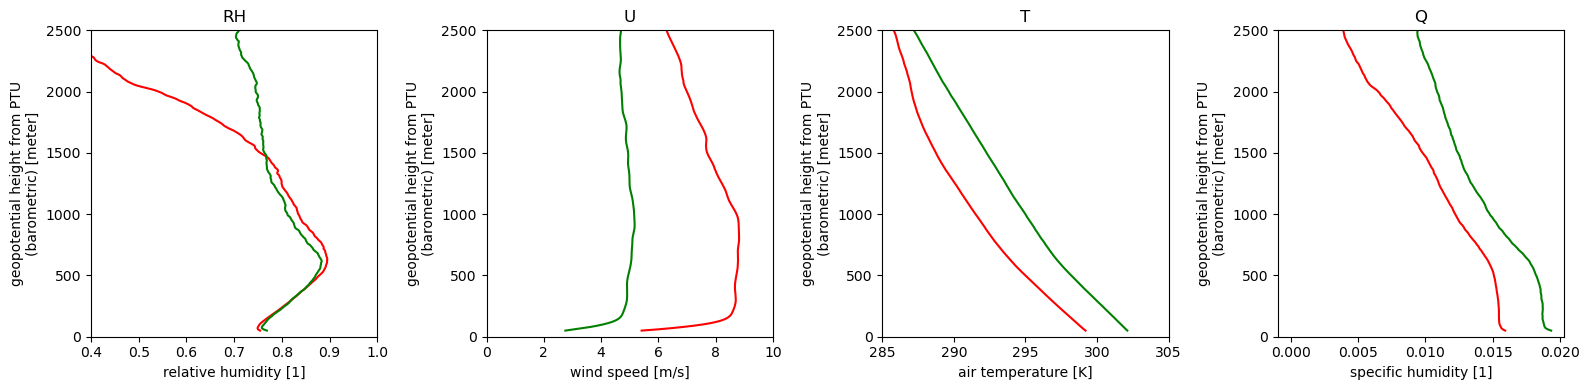

In [7]:
fig, ax = plt.subplots(1,4, figsize=(16,4))

rh_eu.plot.line(ax=ax[0], y="height", color="red")
rh_or.plot.line(ax=ax[0], y="height", color="green")
ax[0].set_title("RH")
ax[0].set_xlim(0.4, 1)

wind_eu.plot.line(ax=ax[1], y="height", color="red")
wind_or.plot.line(ax=ax[1], y="height", color="green")
ax[1].set_title("U")
ax[1].set_xlim(0, 10)


temp_eu.plot.line(ax=ax[2], y="height", color="red")
temp_or.plot.line(ax=ax[2], y="height", color="green")
ax[2].set_title("T")
ax[2].set_xlim(285, 305)


q_eu.plot.line(ax=ax[3], y="height", color="red")
q_or.plot.line(ax=ax[3], y="height", color="green")
ax[3].set_title("Q")
# ax[2].set_xlim(285, 305)



for x in ax:
    x.set_ylim(0,2.5e3)


plt.tight_layout()


In [7]:
## load campaign-mean SST data
ingr_eu = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/EUREC4A_IngrFlux.nc")
sst_eu = ingr_eu.sst.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

ingr_or = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/ORCESTRA_IngrFlux.nc")
sst_or = ingr_or.sst.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

In [8]:
## compute mean q_sfc
from meteo import qsea

sst_local = ingr_eu.sst.sel(cell=[17,24,31,18,25,32, 19,26,33])
q_sfc_eu = qsea(sst_local-273.15, 1013.)
q_sfc_eu = np.mean(q_sfc_eu)

sst_local = ingr_or.sst.sel(cell=[17,24,31,18,25,32, 19,26,33])
q_sfc_or = qsea(sst_local-273.15, 1013.)
q_sfc_or = np.mean(q_sfc_or)

#### do U and q_sfc or fluxes compensate ?

In [9]:
fluxes_eu = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/sfcFluxes_EUREC4A.nc")
lhf_era5_eu = fluxes_eu.lhf.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])
shf_era5_eu = fluxes_eu.shf.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

fuxes_or = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/sfcFluxes_ORCESTRA.nc")
lhf_era5_or = fuxes_or.lhf.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])
shf_era5_or = fuxes_or.shf.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

In [118]:
print(f"Uq EU = {(wind_eu.isel(height=0)*q_sfc_eu):.2f} ; Uq OR = {(wind_or.isel(height=0)*q_sfc_or):.2f}")
print(f"LHF ERA5 EU = {lhf_era5_eu.values:.2f}  ;  LHF ERA5 EU = {lhf_era5_or.values:.2f}")
print("check how the drag coefficients change!")

Uq EU = 119.22 ; Uq OR = 71.95
LHF ERA5 EU = 171.35  ;  LHF ERA5 EU = 134.73
check how the drag coefficients change!


In [120]:
import coare35vn

## ATTENTION: here output only [hsb,hlb, rhoa, Ch,Ce]

u = wind_eu.isel(height=0)
t = temp_eu.isel(height=0)
rh = rh_eu.isel(height=0)
ts = sst_eu
P = 1013.
Rs = ingr_eu.sw_global.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])
Rl = ingr_eu.lw_diff.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

output_eu = coare35vn.coare35vn(u=u.values,
                             t=t.values-273.15,
                             rh=100*rh.values,
                             ts=ts.values-273.15,
                             P=P,
                             Rs=Rs.values,
                             Rl=Rl.values, 
                             zu=50, zt=50, zq=50, lat=13, zi=600, rain=None, cp=None, sigH=None, jcool=1)




u = wind_or.isel(height=0)
t = temp_or.isel(height=0)
rh = rh_or.isel(height=0)
ts = sst_or
P = 1013.
Rs = ingr_or.sw_global.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])
Rl = ingr_or.lw_diff.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

output_or = coare35vn.coare35vn(u=u.values,
                             t=t.values-273.15,
                             rh=100*rh.values,
                             ts=ts.values-273.15,
                             P=P,
                             Rs=Rs.values,
                             Rl=Rl.values, 
                             zu=50, zt=50, zq=50, lat=13, zi=600, rain=None, cp=None, sigH=None, jcool=1)


/work/mh1498/m301248/TCO_data/COARE-algorithm/Python/COARE3.5/meteo.py:156: RuntimeWarning: invalid value encountered in power
  psi = -((1 + 0.6667*zet)**1.5 + 0.6667*(zet - 14.28)*exp(-dzet) + 8.525)


In [122]:
rho_eu, Ch_eu, Ce_eu = output_eu[0,2], output_eu[0,3] , output_eu[0,4]
rho_or, Ch_or, Ce_or = output_or[0,2], output_or[0,3] , output_or[0,4]

lhf_eu_rec, lhf_or_rec = output_eu[0,1], output_or[0,1]
shf_eu_rec, shf_or_rec = output_eu[0,0], output_or[0,0]

In [12]:
print(f"Uq EU = {(wind_eu.isel(height=0)*q_sfc_eu):.2f} ; Uq OR = {(wind_or.isel(height=0)*q_sfc_or):.2f}")
print(f"rho Ce Uq EU = {(rho_eu*Ce_eu*wind_eu.isel(height=0)*q_sfc_eu):.2f} ; rho Ce Uq OR = {(rho_or*Ce_or*wind_or.isel(height=0)*q_sfc_or):.2f}")

print(f"Ce EU = {(Ce_eu):.5f} ; Ce OR = {(Ce_or):.5f}")


print(f"LHF ERA5 EU = {lhf_era5_eu.values:.2f}  ;  LHF ERA5 EU = {lhf_era5_or.values:.2f}")
print(f"LHF EU from prof = {lhf_eu_rec:.2f}  ;  LHF ERA5 EU = {lhf_or_rec:.2f}")


Uq EU = 119.22 ; Uq OR = 71.95
rho Ce Uq EU = 0.16 ; rho Ce Uq OR = 0.11
Ce EU = 0.00113 ; Ce OR = 0.00134
LHF ERA5 EU = 171.35  ;  LHF ERA5 EU = 134.73
LHF EU from prof = 102.70  ;  LHF ERA5 EU = 69.45


In [15]:
import pandas as pd
from IPython.display import display, HTML

data = [
    [r"Uq (m/s g/kg)", f"{(wind_eu.isel(height=0) * q_sfc_eu):.2f}", f"{(wind_or.isel(height=0) * q_sfc_or):.2f}"],
    ["ρCeUq (g / m²s)", f"{(rho_eu * Ce_eu * wind_eu.isel(height=0) * q_sfc_eu):.2f}", f"{(rho_or * Ce_or * wind_or.isel(height=0) * q_sfc_or):.2f}"],
    ["Ce", f"{Ce_eu:.5f}", f"{Ce_or:.5f}"],
    ["Ch", f"{Ch_eu:.5f}", f"{Ch_or:.5f}"],
    ["LHF ERA5 (W/m²)", f"{lhf_era5_eu:.2f}", f"{lhf_era5_or:.2f}"],
    ["LHF from Prof (50m) (W/m²)", f"{lhf_eu_rec:.2f}", f"{lhf_or_rec:.2f}"],
]

# Create DataFrame
df = pd.DataFrame(data, columns=["Quantity", "EU", "OR"])

display(HTML(df.to_html(index=False, table_id="summary-table")))

Quantity,EU,OR
Uq (m/s g/kg),119.22,71.95
ρCeUq (g / m²s),0.16,0.11
Ce,0.00113,0.00134
Ch,0.00113,0.00134
LHF ERA5 (W/m²),171.35,134.73
LHF from Prof (50m) (W/m²),102.70,69.45


In [16]:
## LET'S DOUBLE Ce
# Ce_eu = 2*Ce_eu
# Ce_or = 2*Ce_or

In [13]:
q_out_eu = q_eu.sel(height=entrainment_levels).values*1e3
q_out_or = q_or.sel(height=entrainment_levels).values*1e3

def E(q_out, q_sfc, Vs, W=0.75):
    E = ((W-1)*Vs)/((q_out/q_sfc)-W)
    return E

Vs_lhf_eu = (rho_eu * Ce_eu * wind_eu.isel(height=0)).values  # rho_eu *
Vs_lhf_or = (rho_or * Ce_or * wind_or.isel(height=0)).values  # rho_or *

## compute a series of E values
E_values_eu = E(q_out_eu, q_sfc_eu, Vs_lhf_eu)
E_values_or = E(q_out_or, q_sfc_or, Vs_lhf_or)

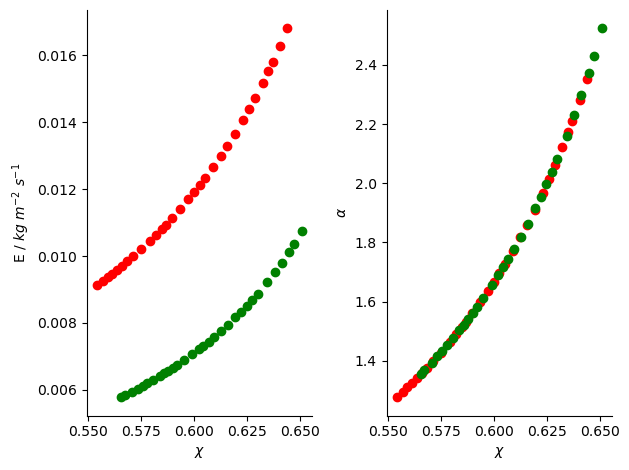

In [14]:
fig, ax = plt.subplots(1,2)

ax[0].scatter(q_out_eu/q_sfc_eu, E_values_eu, color="red", label="EUREC4A")
ax[0].scatter(q_out_or/q_sfc_or, E_values_or, color="green", label="ORCESTRA")

# ax[0].set_xlabel(r"$q_\mathrm{out}$ / $g~kg^{-1}$")
ax[0].set_xlabel(r"$\chi$")
ax[0].set_ylabel(r"E / $kg~m^{-2}~s^{-1}$")


ax[1].scatter(q_out_eu/q_sfc_eu, E_values_eu/Vs_lhf_eu, color="red", label="EUREC4A")
ax[1].scatter(q_out_or/q_sfc_or, E_values_or/Vs_lhf_or, color="green", label="ORCESTRA")

ax[1].set_xlabel(r"$\chi$")
ax[1].set_ylabel(r"$\alpha$")


for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)



plt.tight_layout()
plt.show()

#### use E values in the bulk framework for potential temperature

the temperature equation in the bulk formulation takes the form
$$\theta_\mathrm{bl} = \frac{V_\mathrm{sfc} ~SST + E\theta_\mathrm{out}}{V_\mathrm{sfc}+E} + Radiation$$

In [ ]:
## reduce Ch to half
# Ch_eu = 0.5*Ch_eu
# Ch_or = 0.5*Ch_or

In [15]:
## compute predicted theta and compare with average theta and its variability
theta_eu = ds_eureca_bco.theta.mean(dim="launch_time")
theta_or = ds_orcestra_bco.theta.mean(dim="launch_time")

theta_out_eu = theta_eu.sel(height=entrainment_levels).values
theta_out_or = theta_or.sel(height=entrainment_levels).values

## use Vs for sensible heat exchange
Vs_shf_eu = ( rho_eu * Ch_eu * wind_eu.isel(height=0)).values  # rho_eu *
Vs_shf_or = ( rho_or * Ch_or * wind_or.isel(height=0)).values  # rho_or *

theta_pred_eu = (Vs_shf_eu*sst_eu.values + E_values_eu*theta_out_eu) / (Vs_shf_eu+E_values_eu)
theta_pred_or = (Vs_shf_or*sst_or.values + E_values_or*theta_out_or) / (Vs_shf_or+E_values_or)


## actual mixed-layer averaged theta
theta_bl_eu = theta_eu.sel(height=mixed_avg_levels).mean()
th_var_eu   = ds_eureca_bco.theta.sel(height=mixed_avg_levels).mean(dim="height").std(dim="launch_time")

theta_bl_or = theta_or.sel(height=mixed_avg_levels).mean()
th_var_or   = ds_orcestra_bco.theta.sel(height=mixed_avg_levels).mean(dim="height").std(dim="launch_time")


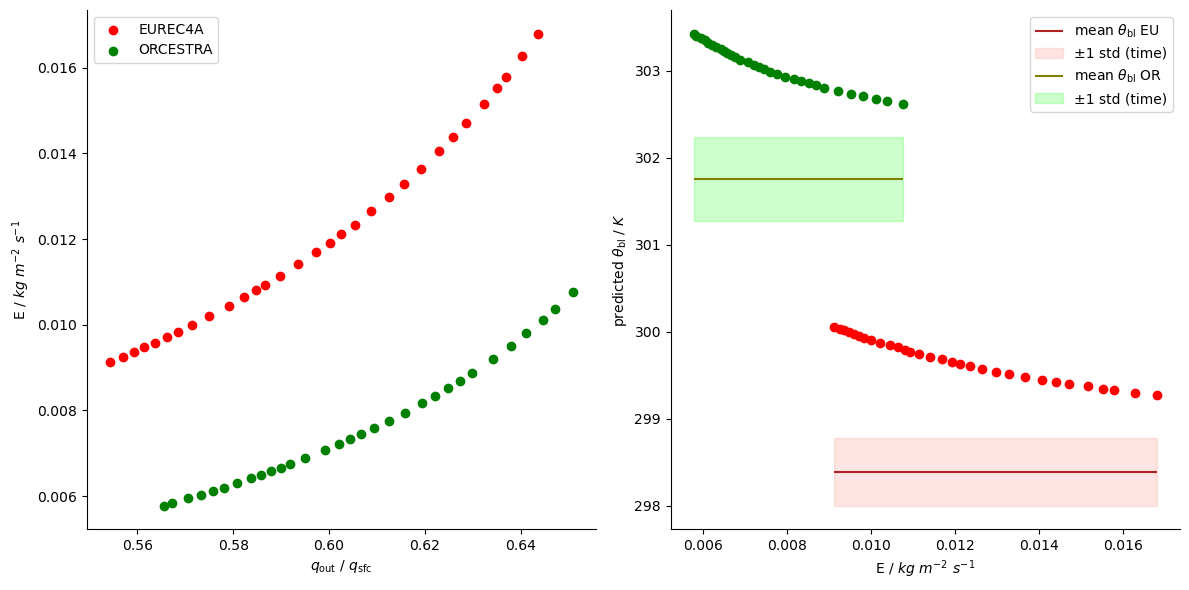

In [16]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))

#### report E for values of q_out
ax[0].scatter(q_out_eu/q_sfc_eu, E_values_eu, color="red", label="EUREC4A")
ax[0].scatter(q_out_or/q_sfc_or, E_values_or, color="green", label="ORCESTRA")

ax[0].set_xlabel(r"$q_\mathrm{out}$ / $q_\mathrm{sfc}$")
# ax[0].set_xlabel(r"$\chi$")
ax[0].set_ylabel(r"E / $kg~m^{-2}~s^{-1}$")
ax[0].legend()






#### compare predicted theta with actual theta

ax[1].scatter(E_values_eu, theta_pred_eu, color="red")
ax[1].scatter(E_values_or, theta_pred_or, color="green")

ax[1].hlines(theta_bl_eu, xmin=np.min(E_values_eu), xmax=np.max(E_values_eu), color="firebrick", label=r"mean $\theta_\mathrm{bl}$ EU")
ax[1].fill_between(
    [np.min(E_values_eu), np.max(E_values_eu)],
    (theta_bl_eu - th_var_eu) ,
    (theta_bl_eu + th_var_eu) ,
    color="salmon",
    alpha=0.2,
    label='±1 std (time)'
)



ax[1].hlines(theta_bl_or, xmin=np.min(E_values_or), xmax=np.max(E_values_or), color="olive", label=r"mean $\theta_\mathrm{bl}$ OR")
ax[1].fill_between(
    [np.min(E_values_or), np.max(E_values_or)],
    (theta_bl_or - th_var_or) ,
    (theta_bl_or + th_var_or) ,
    color="lime",
    alpha=0.2,
    label='±1 std (time)'
)



ax[1].set_xlabel(r"E / $kg~m^{-2}~s^{-1}$")
ax[1].set_ylabel(r"predicted $\theta_\mathrm{bl}$ / $K$")
ax[1].legend()

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)



plt.tight_layout()
plt.show()

##### include radiation: Yokoi and Katsumata 2022

In [17]:
eps = 0.14
oc_abs = 0.97        ## ocean absorptivity == emissivity
stefan = 5.67*1e-8
eta = 0.02
oc_alb = 0.055

def rad_terms(sw_in, lw_in, sst):
    return (eps/(1-eps))*lw_in +eps*oc_abs*stefan*(sst)**4 + ((eta//(1-eta)) + eta*(1-oc_alb))*sw_in

In [18]:
non_thBL_terms_eu = rad_terms(ingr_eu.sw_global.sel(cell=0).mean(dim="time").values, ingr_eu.lw_diff.sel(cell=0).mean(dim="time").values, sst_eu.values)
non_thBL_terms_or = rad_terms(ingr_or.sw_global.sel(cell=0).mean(dim="time").values, ingr_or.lw_diff.sel(cell=0).mean(dim="time").values, sst_or.values)

In [19]:
## rho = p / (R Tv)
rho_E_eu = (ds_eureca_bco.p/(Rd*ds_eureca_bco.ta*(1+0.61*ds_eureca_bco.mr))).mean("launch_time").sel(height=entrainment_levels).values
rho_E_or = (ds_orcestra_bco.p/(Rd*ds_orcestra_bco.ta*(1+0.61*ds_orcestra_bco.mr))).mean("launch_time").sel(height=entrainment_levels).values

In [20]:
theta_predRad_eu = np.zeros_like(E_values_eu)
theta_predRad_or = np.zeros_like(E_values_or)

## EUREC4A DATA

for i, E in enumerate(E_values_eu):
    # Define the coefficients of the quartic: a*x^4 + b*x^3 + c*x^2 + d*x + e = 0
    coeffs = [
        -((2 - eps) / (1 - eps)) * eps * stefan,  # a (x^4)
        0,                                        # b (x^3)
        0,                                        # c (x^2)
        -(1.*cp*Vs_shf_eu +rho_E_eu[i]*cp*E),                             # d (x^1)
        1.*cp*Vs_shf_eu * sst_eu.values + rho_E_eu[i]*cp*E * theta_out_eu[i] + non_thBL_terms_eu  # e (constant)
    ]
    
    # Solve the polynomial
    roots = np.roots(coeffs)
    
    # Filter only the fully real roots (no imaginary part)
    real_roots = roots[np.isreal(roots)]
    real_roots = np.real(real_roots) 
    
    # Now filter for physically meaningful (positive) roots
    positive_real_roots = real_roots[real_roots > 0]
    
    if len(positive_real_roots) > 0:
        theta_predRad_eu[i] = np.max(positive_real_roots)



## ORCESTRA DATA

for i, E in enumerate(E_values_or):
    # Define the coefficients of the quartic: a*x^4 + b*x^3 + c*x^2 + d*x + e = 0
    coeffs = [
        -((2 - eps) / (1 - eps)) * eps * stefan,  # a (x^4)
        0,                                        # b (x^3)
        0,                                        # c (x^2)
        -(rho_eu*cp*Vs_shf_or + rho_E_or[i]*cp*E),                             # d (x^1)
        rho_eu*cp*Vs_shf_or * sst_or.values + rho_E_or[i]*cp*E * theta_out_or[i] + non_thBL_terms_or  # e (constant)
    ]
    
    # Solve the polynomial
    roots = np.roots(coeffs)
    
    # Filter only the fully real roots (no imaginary part)
    real_roots = roots[np.isreal(roots)]
    real_roots = np.real(real_roots)
    
    # Now filter for physically meaningful (positive) roots
    positive_real_roots = real_roots[real_roots > 0]
    
    if len(positive_real_roots) > 0:
        theta_predRad_or[i] = np.max(positive_real_roots)

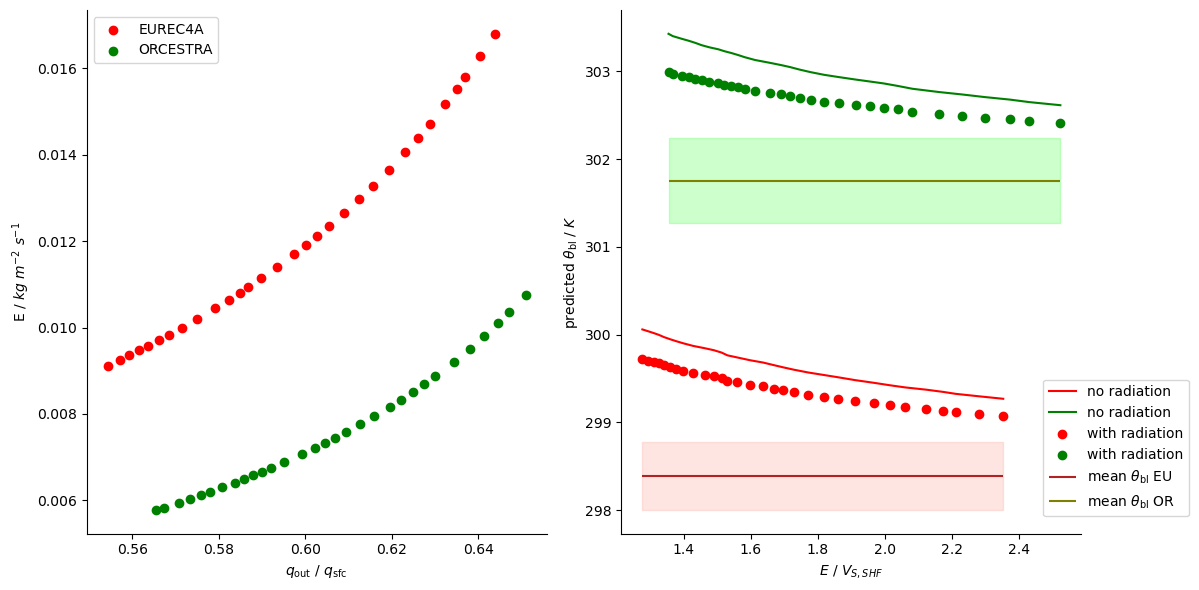

In [21]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))

#### report E for values of q_out
ax[0].scatter(q_out_eu/q_sfc_eu, E_values_eu, color="red", label="EUREC4A")
ax[0].scatter(q_out_or/q_sfc_or, E_values_or, color="green", label="ORCESTRA")

ax[0].set_xlabel(r"$q_\mathrm{out}$ / $q_\mathrm{sfc}$")
# ax[0].set_xlabel(r"$\chi$")
ax[0].set_ylabel(r"E / $kg~m^{-2}~s^{-1}$")
ax[0].legend()






#### compare predicted theta with actual theta
ax[1].plot(E_values_eu/Vs_shf_eu, theta_pred_eu, color="red", label="no radiation")
ax[1].plot(E_values_or/Vs_shf_or, theta_pred_or, color="green", label="no radiation")

ax[1].scatter(E_values_eu/Vs_shf_eu, theta_predRad_eu, color="red", label="with radiation")
ax[1].scatter(E_values_or/Vs_shf_or, theta_predRad_or, color="green", label="with radiation")

ax[1].hlines(theta_bl_eu, xmin=np.min(E_values_eu/Vs_shf_eu), xmax=np.max(E_values_eu/Vs_shf_eu), color="firebrick", label=r"mean $\theta_\mathrm{bl}$ EU")
ax[1].fill_between(
    [np.min(E_values_eu/Vs_shf_eu), np.max(E_values_eu/Vs_shf_eu)],
    (theta_bl_eu - th_var_eu) ,
    (theta_bl_eu + th_var_eu) ,
    color="salmon",
    alpha=0.2
)



ax[1].hlines(theta_bl_or, xmin=np.min(E_values_or/Vs_shf_or), xmax=np.max(E_values_or/Vs_shf_or), color="olive", label=r"mean $\theta_\mathrm{bl}$ OR")
ax[1].fill_between(
    [np.min(E_values_or/Vs_shf_or), np.max(E_values_or/Vs_shf_or)],
    (theta_bl_or - th_var_or) ,
    (theta_bl_or + th_var_or) ,
    color="lime",
    alpha=0.2
)



ax[1].set_xlabel(r"$E$ / $V_{S,SHF}$ ") #/ $kg~m^{-2}~s^{-1}$")
ax[1].set_ylabel(r"predicted $\theta_\mathrm{bl}$ / $K$")
ax[1].legend(loc="lower right", bbox_to_anchor=(1.25,0.02))

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)



plt.tight_layout()
plt.show()

What if we treat E as convective downdraft? Meaning that now

$$ E = D = \frac{\left( 1 - W_\mathrm{sfc} \right) \cdot V_\mathrm{sfc}}{W - q^*_{cd}/q^*_\mathrm{sfc}} $$

In [22]:
downdraft_levels_eu = slice(750, 1000)
downdraft_levels_or = slice(1000, 1500)

In [23]:
# function to invert is
# h_cd / cp = \theta_cd + Lv/cp * qs(\theta_cd)

def temp_from_h(theta, p, h_cd, Lv, cp):
    es = 6.1121 * np.exp(17.502 * (theta-273.15) / (240.97 + (theta-273.15)))
    denominator = p - 0.378 * es * (1.0007 + p * 3.46e-6)
    
    return h_cd/cp - theta - (Lv / cp) * 0.622 * es * (1.0007 + p * 3.46e-6) / denominator


## data to use
h_cd_eu = (cp*ds_eureca_bco["ta"] + Lv*ds_eureca_bco["mr"] + g*ds_eureca_bco.height).mean(dim="launch_time").sel(height=downdraft_levels_eu)
h_cd_or = (cp*ds_orcestra_bco["ta"] + Lv*ds_orcestra_bco["mr"] + g*ds_orcestra_bco.height).mean(dim="launch_time").sel(height=downdraft_levels_or)

p_cd_eu = ds_eureca_bco["p"].mean(dim="launch_time").sel(height=downdraft_levels_eu)
p_cd_or = ds_orcestra_bco["p"].mean(dim="launch_time").sel(height=downdraft_levels_or)



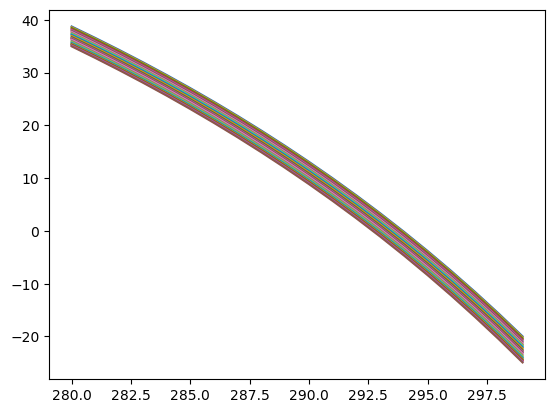

In [24]:
t = np.arange(280, 300)
vect_temp = np.vectorize(temp_from_h)

for x in zip(p_cd_eu, h_cd_eu):
    function_res = vect_temp(t, p=x[0]/100., h_cd=x[1], Lv=Lv, cp=cp)
    plt.plot(t, function_res)


In [25]:
def f_eu(t):
    return temp_from_h(t, p=p_cd_eu[0]/100., h_cd=h_cd_eu[0], Lv=Lv, cp=cp)

def f_or(t):
    return temp_from_h(t, p=p_cd_or[0]/100., h_cd=h_cd_or[0], Lv=Lv, cp=cp)



from scipy.optimize import root_scalar

try:
    sol_or = root_scalar(f_or, bracket=[280, 300], method='brentq')
    
    if sol_or.converged:
        t_root = sol_or.root
        print(f"Root found at theta = {t_root:.4f} K")
    else:
        print("Root finding did not converge.")
except Exception as e:
    print(f"Error: {e}")

Root found at theta = 295.4309 K


##### extend to arrays of values

In [26]:
# Wrap the root-finding in a vectorized function
def find_root_for_pair(p, h):
    def f(t):
        return temp_from_h(t, p=p, h_cd=h, Lv=Lv, cp=cp)
    
    try:
        sol = root_scalar(f, bracket=[280, 300], method='brentq')
        return sol.root if sol.converged else np.nan
    except:
        return np.nan

# Vectorize the function
vectorized_root = np.vectorize(find_root_for_pair)



In [27]:
# Apply to arrays
thetaD_eu = vectorized_root(p_cd_eu / 100., h_cd_eu)
thetaD_or = vectorized_root(p_cd_or / 100., h_cd_or)

In [28]:
qSat_out_eu = meteo.qsea(  thetaD_eu-273.15 , p_cd_eu/100  )
qSat_out_or = meteo.qsea(  thetaD_or-273.15 , p_cd_or/100  )

In [29]:
'''
g = 9.81   # m/s2

method = input("what method of saturation calculation? direct or yk ")

while method not in ["direct", "yk"]:
    method = input("no matching method, try again")
if method == "direct":
    ## direct formulation : use local saturation vaue obtained by just dividing by RH
    qSat_out_eu = (q_eu.sel(height=downdraft_levels_eu).values*1e3)/rh_eu.sel(height=downdraft_levels_eu).values
    qSat_out_or = (q_or.sel(height=downdraft_levels_or).values*1e3)/rh_or.sel(height=downdraft_levels_or).values

elif method == "yk":
    ref_BL_press = 975.      ## hPa
    ## Yokoi and Katsumata
    T_satD_eu = (ds_eureca_bco.ta + g*ds_eureca_bco.ta.height/cp).mean(dim="launch_time")
    qSat_out_eu = meteo.qsea(  T_satD_eu.sel(height=downdraft_levels_eu) -273.15 , ref_BL_press  )     #press_eu.sel(height=downdraft_levels_eu)

    T_satD_or = (ds_orcestra_bco.ta + g*ds_orcestra_bco.ta.height/cp).mean(dim="launch_time")
    qSat_out_or = meteo.qsea(  T_satD_or.sel(height=downdraft_levels_or) -273.15 , ref_BL_press  )     #press_eu.sel(height=downdraft_levels_or)
    
'''

def D_here(q_out, q_sfc, Vs, W=0.75):
    E = ((W-1)*Vs)/((q_out/q_sfc)-W)
    return E

Vs_lhf_eu = (rho_eu * Ce_eu * wind_eu.isel(height=0)).values  # rho_eu * 
Vs_lhf_or = (rho_or * Ce_or * wind_or.isel(height=0)).values  # rho_or * 

## compute a series of E values
D_values_eu = D_here(qSat_out_eu, q_sfc_eu, Vs_lhf_eu)
D_values_or = D_here(qSat_out_or, q_sfc_or, Vs_lhf_or)

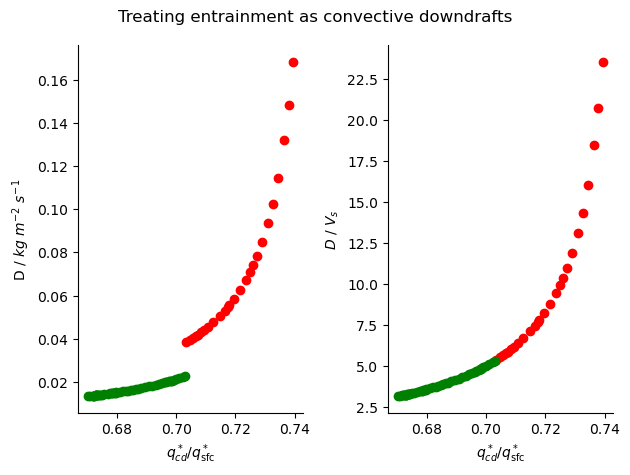

In [30]:
fig, ax = plt.subplots(1,2)
fig.suptitle("Treating entrainment as convective downdrafts")

ax[0].scatter(qSat_out_eu/q_sfc_eu, D_values_eu, color="red", label="EUREC4A")
ax[0].scatter(qSat_out_or/q_sfc_or, D_values_or, color="green", label="ORCESTRA")

# ax[0].set_xlabel(r"$q_\mathrm{out}$ / $g~kg^{-1}$")
ax[0].set_xlabel(r"$q^*_{cd}/q^*_\mathrm{sfc}$")
ax[0].set_ylabel(r"D / $kg~m^{-2}~s^{-1}$")


ax[1].scatter(qSat_out_eu/q_sfc_eu, D_values_eu/Vs_lhf_eu, color="red", label="EUREC4A")
ax[1].scatter(qSat_out_or/q_sfc_or, D_values_or/Vs_lhf_or, color="green", label="ORCESTRA")

ax[1].set_xlabel(r"$q^*_{cd}/q^*_\mathrm{sfc}$")
ax[1].set_ylabel(r"$D ~ / ~ V_s $")


for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)



plt.tight_layout()
plt.show()

In [31]:
## compute predicted theta and compare with average theta and its variability
theta_eu = ds_eureca_bco.theta.mean(dim="launch_time")
theta_or = ds_orcestra_bco.theta.mean(dim="launch_time")
'''
thetaD_out_eu = theta_eu.sel(height=downdraft_levels_eu).values
thetaD_out_or = theta_or.sel(height=downdraft_levels_or).values

using 
thetaD_eu
thetaD_or
calculated as in Yokoi and Katsumata 2022
'''

## use Vs for sensible heat exchange
Vs_shf_eu = ( rho_eu * Ch_eu * wind_eu.isel(height=0)).values   # rho_eu * 
Vs_shf_or = ( rho_or * Ch_or * wind_or.isel(height=0)).values   # rho_or *

thetaD_pred_eu = (Vs_shf_eu*sst_eu.values + D_values_eu*thetaD_eu) / (Vs_shf_eu+D_values_eu)
thetaD_pred_or = (Vs_shf_or*sst_or.values + D_values_or*thetaD_or) / (Vs_shf_or+D_values_or)


## actual mixed-layer averaged theta
theta_bl_eu = theta_eu.sel(height=mixed_avg_levels).mean()
th_var_eu   = ds_eureca_bco.theta.sel(height=mixed_avg_levels).mean(dim="height").std(dim="launch_time")

theta_bl_or = theta_or.sel(height=mixed_avg_levels).mean()
th_var_or   = ds_orcestra_bco.theta.sel(height=mixed_avg_levels).mean(dim="height").std(dim="launch_time")


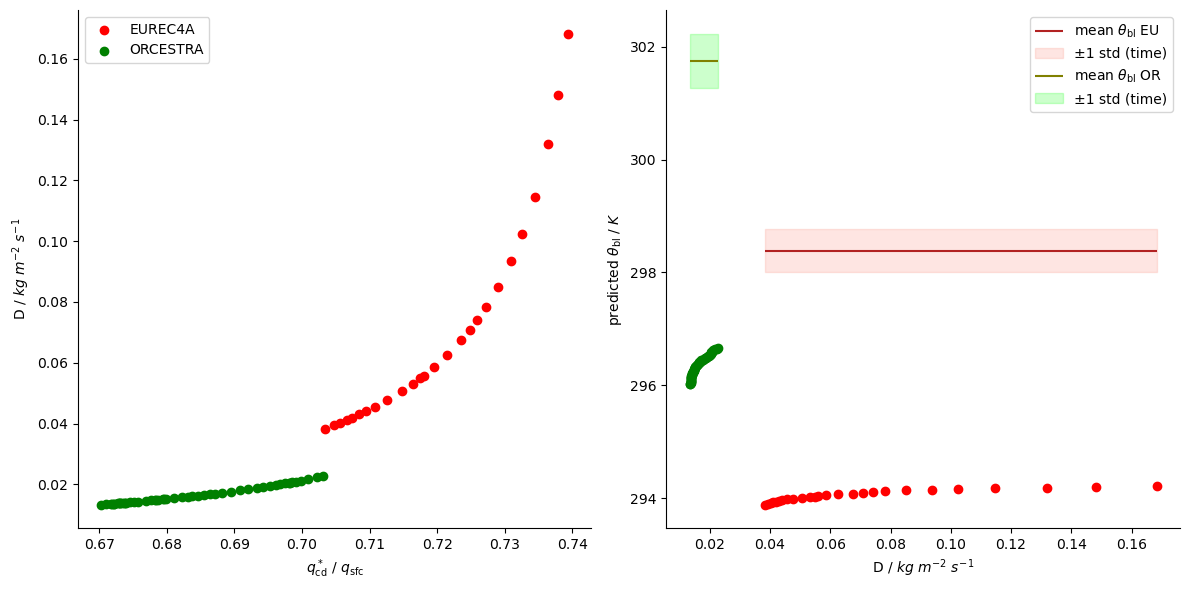

In [32]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))

#### report E for values of q_out
ax[0].scatter(qSat_out_eu/q_sfc_eu, D_values_eu, color="red", label="EUREC4A")
ax[0].scatter(qSat_out_or/q_sfc_or, D_values_or, color="green", label="ORCESTRA")

ax[0].set_xlabel(r"$q^*_\mathrm{cd}$ / $q_\mathrm{sfc}$")
# ax[0].set_xlabel(r"$\chi$")
ax[0].set_ylabel(r"D / $kg~m^{-2}~s^{-1}$")
ax[0].legend()






#### compare predicted theta with actual theta

ax[1].scatter(D_values_eu, thetaD_pred_eu, color="red")
ax[1].scatter(D_values_or, thetaD_pred_or, color="green")

ax[1].hlines(theta_bl_eu, xmin=np.min(D_values_eu), xmax=np.max(D_values_eu), color="firebrick", label=r"mean $\theta_\mathrm{bl}$ EU")
ax[1].fill_between(
    [np.min(D_values_eu), np.max(D_values_eu)],
    (theta_bl_eu - th_var_eu) ,
    (theta_bl_eu + th_var_eu) ,
    color="salmon",
    alpha=0.2,
    label='±1 std (time)'
)



ax[1].hlines(theta_bl_or, xmin=np.min(D_values_or), xmax=np.max(D_values_or), color="olive", label=r"mean $\theta_\mathrm{bl}$ OR")
ax[1].fill_between(
    [np.min(D_values_or), np.max(D_values_or)],
    (theta_bl_or - th_var_or) ,
    (theta_bl_or + th_var_or) ,
    color="lime",
    alpha=0.2,
    label='±1 std (time)'
)



ax[1].set_xlabel(r"D / $kg~m^{-2}~s^{-1}$")
ax[1].set_ylabel(r"predicted $\theta_\mathrm{bl}$ / $K$")
ax[1].legend()

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)



plt.tight_layout()
plt.show()

In [33]:
non_thBL_terms_eu = rad_terms(ingr_eu.sw_global.sel(cell=0).mean(dim="time").values, ingr_eu.lw_diff.sel(cell=0).mean(dim="time").values, sst_eu.values)
non_thBL_terms_or = rad_terms(ingr_or.sw_global.sel(cell=0).mean(dim="time").values, ingr_or.lw_diff.sel(cell=0).mean(dim="time").values, sst_or.values)

In [34]:
## compute air density at levels where it is entrained or falling

## SHOULD NOT NEED THIS ANYMORE IF THE SURFACE Vs is ALREADY A MASS FLUX

Rd = 287.

## rho = p / (R Tv)
'''rho_D_eu = (ds_eureca_bco.p/(Rd*ds_eureca_bco.ta*(1+0.61*ds_eureca_bco.mr))).mean("launch_time").sel(height=downdraft_levels_eu).values
rho_D_or = (ds_orcestra_bco.p/(Rd*ds_orcestra_bco.ta*(1+0.61*ds_orcestra_bco.mr))).mean("launch_time").sel(height=downdraft_levels_or).values'''

'rho_D_eu = (ds_eureca_bco.p/(Rd*ds_eureca_bco.ta*(1+0.61*ds_eureca_bco.mr))).mean("launch_time").sel(height=downdraft_levels_eu).values\nrho_D_or = (ds_orcestra_bco.p/(Rd*ds_orcestra_bco.ta*(1+0.61*ds_orcestra_bco.mr))).mean("launch_time").sel(height=downdraft_levels_or).values'

In [35]:
thetaD_predRad_eu = np.zeros_like(D_values_eu)
thetaD_predRad_or = np.zeros_like(D_values_or)



## EUREC4A DATA

for i, D in enumerate(D_values_eu):
    # Define the coefficients of the quartic: a*x^4 + b*x^3 + c*x^2 + d*x + e = 0
    coeffs = [
        -((2 - eps) / (1 - eps)) * eps * stefan,  # a (x^4)
        0,                                        # b (x^3)
        0,                                        # c (x^2)
        -(cp*Vs_shf_eu + cp*D),                             # d (x^1)
        cp*Vs_shf_eu * sst_eu.values + cp*D * thetaD_eu[i] + non_thBL_terms_eu  # e (constant)
    ]
    
    # Solve the polynomial
    roots = np.roots(coeffs)
    
    # Filter only the fully real roots (no imaginary part)
    real_roots = roots[np.isreal(roots)]
    real_roots = np.real(real_roots) 
    
    # Now filter for physically meaningful (positive) roots
    positive_real_roots = real_roots[real_roots > 0]
    
    if len(positive_real_roots) > 0:
        thetaD_predRad_eu[i] = np.max(positive_real_roots)



## ORCESTRA DATA

for i, D in enumerate(D_values_or):
    # Define the coefficients of the quartic: a*x^4 + b*x^3 + c*x^2 + d*x + e = 0
    coeffs = [
        -((2 - eps) / (1 - eps)) * eps * stefan,  # a (x^4)
        0,                                        # b (x^3)
        0,                                        # c (x^2)
        -(1.*cp*Vs_shf_or + 0.8*cp*D),                             # d (x^1)
        1.*cp*Vs_shf_or * sst_or.values + 0.8*cp*D * thetaD_or[i] + non_thBL_terms_or  # e (constant)
    ]
    
    # Solve the polynomial
    roots = np.roots(coeffs)
    
    # Filter only the fully real roots (no imaginary part)
    real_roots = roots[np.isreal(roots)]
    real_roots = np.real(real_roots)
    
    # Now filter for physically meaningful (positive) roots
    positive_real_roots = real_roots[real_roots > 0]
    
    if len(positive_real_roots) > 0:
        thetaD_predRad_or[i] = np.max(positive_real_roots)

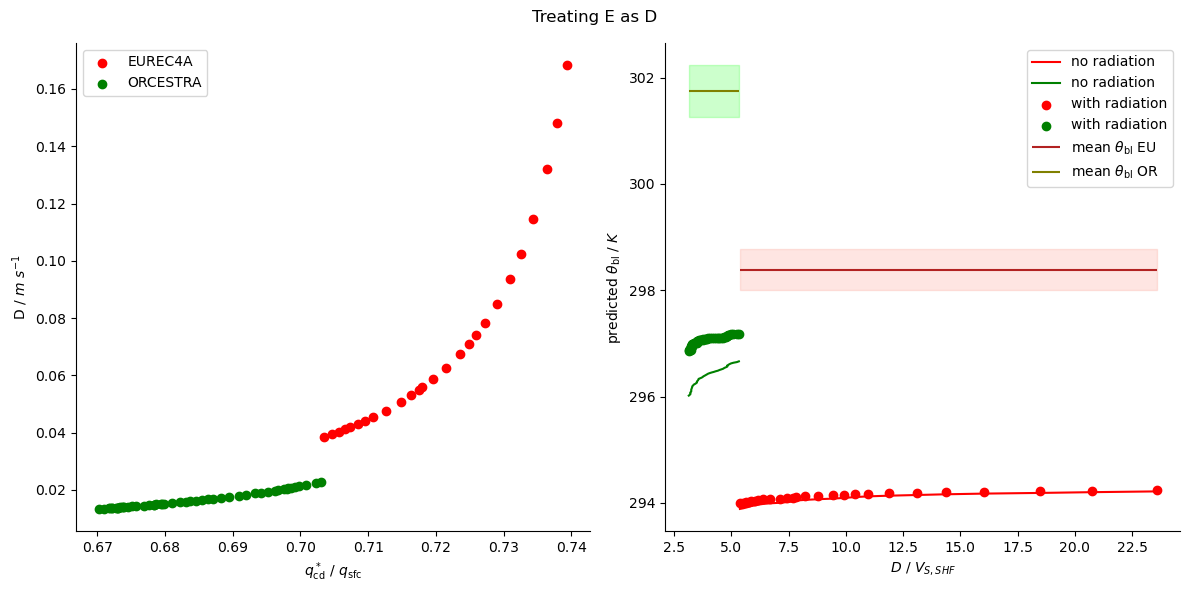

In [36]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
fig.suptitle("Treating E as D")

#### report E for values of q_out
ax[0].scatter(qSat_out_eu/q_sfc_eu, D_values_eu, color="red", label="EUREC4A")
ax[0].scatter(qSat_out_or/q_sfc_or, D_values_or, color="green", label="ORCESTRA")

ax[0].set_xlabel(r"$q^*_\mathrm{cd}$ / $q_\mathrm{sfc}$")
# ax[0].set_xlabel(r"$\chi$")
ax[0].set_ylabel(r"D / $m~s^{-1}$")
ax[0].legend()






#### compare predicted theta with actual theta
ax[1].plot(D_values_eu/Vs_shf_eu, thetaD_pred_eu, color="red", label="no radiation")
ax[1].plot(D_values_or/Vs_shf_or, thetaD_pred_or, color="green", label="no radiation")

ax[1].scatter(D_values_eu/Vs_shf_eu, thetaD_predRad_eu, color="red", label="with radiation")
ax[1].scatter(D_values_or/Vs_shf_or, thetaD_predRad_or, color="green", label="with radiation")

ax[1].hlines(theta_bl_eu, xmin=np.min(D_values_eu/Vs_shf_eu), xmax=np.max(D_values_eu/Vs_shf_eu), color="firebrick", label=r"mean $\theta_\mathrm{bl}$ EU")
ax[1].fill_between(
    [np.min(D_values_eu/Vs_shf_eu), np.max(D_values_eu/Vs_shf_eu)],
    (theta_bl_eu - th_var_eu) ,
    (theta_bl_eu + th_var_eu) ,
    color="salmon",
    alpha=0.2
)



ax[1].hlines(theta_bl_or, xmin=np.min(D_values_or/Vs_shf_or), xmax=np.max(D_values_or/Vs_shf_or), color="olive", label=r"mean $\theta_\mathrm{bl}$ OR")
ax[1].fill_between(
    [np.min(D_values_or/Vs_shf_or), np.max(D_values_or/Vs_shf_or)],
    (theta_bl_or - th_var_or) ,
    (theta_bl_or + th_var_or) ,
    color="lime",
    alpha=0.2
)



ax[1].set_xlabel(r"$D$ / $V_{S,SHF}$ ") #/ $kg~m^{-2}~s^{-1}$")
ax[1].set_ylabel(r"predicted $\theta_\mathrm{bl}$ / $K$")
ax[1].legend(loc="upper right")   #, bbox_to_anchor=(1.25,0.02))

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)



plt.tight_layout()
plt.show()

## Merging the two with a local MSE budget

With my current nomenclature and Yokoi and Katsumata 2022:

$$V_{s,SHF} \cdot (SST - \theta_{BL}) + m_{E} \cdot (\theta_E - \theta_{BL}) + m_{cd} \cdot (\theta_{cd} - \theta_{BL}) + R/c_p = 0$$
$$V_{s,LHF} \cdot (q^*_{sfc} - q_{BL}) + m_{E} \cdot (q_E - q_{BL}) + m_{cd} \cdot (q^*_{cd} - q_{BL}) = 0$$


actually, I should use the ERA5 surface heat fluxes 

$$H/c_p + m_{E} \cdot (\theta_E - \theta_{BL}) + m_{cd} \cdot (\theta_{cd} - \theta_{BL}) + R/c_p = 0$$
$$LH/L_v + m_{E} \cdot (q_E - q_{BL}) + m_{cd} \cdot (q^*_{cd} - q_{BL}) = 0$$

In [47]:
entrainment_levels = slice(700, 800)

downdraft_levels_eu = slice(1000, 2000)
downdraft_levels_or = slice(2500, 3500)

In [48]:
## load campaign-mean SST data
ingr_eu = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/EUREC4A_IngrFlux.nc")
sst_eu = ingr_eu.sst.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

ingr_or = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/ORCESTRA_IngrFlux.nc")
sst_or = ingr_or.sst.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

In [49]:
eps = 0.14
oc_abs = 0.97        ## ocean absorptivity == emissivity
stefan = 5.67*1e-8
eta = 0.02
oc_alb = 0.055

def rad_terms(sw_in, lw_in, sst):
    return (eps/(1-eps))*lw_in +eps*oc_abs*stefan*(sst)**4 + ((eta//(1-eta)) + eta*(1-oc_alb))*sw_in

non_thBL_terms_eu = rad_terms(ingr_eu.sw_global.sel(cell=0).mean(dim="time").values, ingr_eu.lw_diff.sel(cell=0).mean(dim="time").values, sst_eu.values)
non_thBL_terms_or = rad_terms(ingr_or.sw_global.sel(cell=0).mean(dim="time").values, ingr_or.lw_diff.sel(cell=0).mean(dim="time").values, sst_or.values)

In [50]:
fluxes_eu = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/sfcFluxes_EUREC4A.nc")
lhf_era5_eu = fluxes_eu.lhf.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])
shf_era5_eu = fluxes_eu.shf.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

fuxes_or = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/sfcFluxes_ORCESTRA.nc")
lhf_era5_or = fuxes_or.lhf.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])
shf_era5_or = fuxes_or.shf.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"])

In [51]:
## compute thetaD
from scipy.optimize import root_scalar

def temp_from_h(theta, p, h_cd, Lv, cp):
    es = 6.1121 * np.exp(17.502 * (theta-273.15) / (240.97 + (theta-273.15)))
    denominator = p - 0.378 * es * (1.0007 + p * 3.46e-6)
    
    return h_cd/cp - theta - (Lv / cp) * 0.622 * es * (1.0007 + p * 3.46e-6) / denominator


def find_theta_for_pair(p, h):
    # def f(t):
    #     return temp_from_h(t, p=p, h_cd=h, Lv=Lv, cp=cp)
    
    f = lambda t : temp_from_h(t, p=p, h_cd=h, Lv=Lv, cp=cp)

    try:
        sol = root_scalar(f, bracket=[285,295], method='brentq')
        return sol.root if sol.converged else np.nan
    except Exception as e:
        print(f"Exception for p={p:.2f}, h={h:.2f}: {e}")
        return np.nan




In [52]:
## data to use
h_cd_eu = (cp*ds_eureca_bco["ta"] + Lv*ds_eureca_bco["mr"] + g*ds_eureca_bco.height).mean(dim="launch_time").sel(height=downdraft_levels_eu)
h_cd_or = (cp*ds_orcestra_bco["ta"] + Lv*ds_orcestra_bco["mr"] + g*ds_orcestra_bco.height).mean(dim="launch_time").sel(height=downdraft_levels_or)

p_cd_eu = ds_eureca_bco["p"].mean(dim="launch_time").sel(height=downdraft_levels_eu).values
p_cd_or = ds_orcestra_bco["p"].mean(dim="launch_time").sel(height=downdraft_levels_or).values


# since I am working with arrays
vectorized_theta_root = np.vectorize(find_theta_for_pair)

# Apply to arrays
thetaD_eu = vectorized_theta_root(p_cd_eu / 100., h_cd_eu)
thetaD_or = vectorized_theta_root(p_cd_or / 100., h_cd_or)




from metpy.units import units
ref_p = metpy.calc.height_to_pressure_std(600*units.m)
ref_p = ref_p.to(units.hPa).magnitude

# compute corresponding saturation humidity in the BL
qSat_out_eu = meteo.qsea(  thetaD_eu-273.15 , 1000.  )/1e3    # kg / kg   # p_cd_eu/100
qSat_out_or = meteo.qsea(  thetaD_or-273.15 , 1000.  )/1e3    # kg / kg   # p_cd_or/100

In [53]:
## all theta data
theta_eu = ds_eureca_bco.theta.mean(dim="launch_time")
theta_or = ds_orcestra_bco.theta.mean(dim="launch_time")

'''thetaD_out_eu = theta_eu.isel(height=downdraft_levels_idx_eu).mean(dim="height").values
thetaD_out_or = theta_or.isel(height=downdraft_levels_idx_or).mean(dim="height").values'''

theta_out_eu = theta_eu.sel(height=entrainment_levels).values
theta_out_or = theta_or.sel(height=entrainment_levels).values

theta_bl_eu = theta_eu.sel(height=mixed_avg_levels).mean()
theta_bl_or = theta_or.sel(height=mixed_avg_levels).mean()


## all humidity data
q_eu = ds_eureca_bco.q.mean(dim="launch_time")
q_or = ds_orcestra_bco.q.mean(dim="launch_time")

'''qSat_out_eu = ((q_eu.isel(height=downdraft_levels_idx_eu).values)/rh_eu.isel(height=downdraft_levels_idx_eu)).mean(dim="height").values
qSat_out_or = ((q_or.isel(height=downdraft_levels_idx_or).values)/rh_or.isel(height=downdraft_levels_idx_or)).mean(dim="height").values'''

q_out_eu = q_eu.sel(height=entrainment_levels).values
q_out_or = q_or.sel(height=entrainment_levels).values

q_bl_eu = q_eu.sel(height=mixed_avg_levels).mean()
q_bl_or = q_or.sel(height=mixed_avg_levels).mean()


In [59]:
############  matrix coefficients
cp = 1004. 
Lv = 2.5e6

## save resulting values, depending on height selected
me_eu, me_or = [], []
mD_eu, mD_or = [], []


##
 
for i in range(theta_out_eu.size): # theta_out_eu.shape
    A_eu = np.array([
        [
            theta_out_eu[i] - theta_bl_eu,  np.nanmean(thetaD_eu) - theta_bl_eu
        ],
        [
            q_out_eu[i] - q_bl_eu,          np.nanmean(qSat_out_eu) - q_bl_eu
        ]
    ])

    b_eu = np.array([
        - shf_era5_eu.values/cp - (non_thBL_terms_eu - ((2 - eps)/(1 - eps))*eps*stefan*(theta_bl_eu.values)**4)/cp ,
        - lhf_era5_eu.values / Lv
    ])

    ## shf and lhf _rec are the ones obtained from radiosoundings applied to COARE routines

    # b_eu = np.array([
    #     - shf_eu_rec / cp - (non_thBL_terms_eu - ((2 - eps)/(1 - eps))*eps*stefan*(theta_bl_eu.values)**4)/cp ,
    #     - lhf_eu_rec / Lv
    # ])
    
    x_eu = np.linalg.pinv(A_eu) @ b_eu

    me_eu.append(x_eu[0])
    mD_eu.append(x_eu[1])


for i in range(theta_out_or.size):
    A_or = np.array([
        [
            theta_out_or[i] - theta_bl_or,    np.nanmean(thetaD_or) - theta_bl_or
        ],
        [
            q_out_or[i] - q_bl_or,            np.nanmean(qSat_out_or) - q_bl_or
        ]
    ])

    b_or = np.array([
        - shf_era5_or.values/cp - ( non_thBL_terms_or - ((2 - eps)/(1 - eps))*eps*stefan*(theta_bl_or)**4 )/cp,
        - lhf_era5_or.values/Lv 
    ])

    ## shf and lhf _rec are the ones obtained from radiosoundings applied to COARE routines

    # b_or = np.array([
    #     - shf_or_rec/cp - ( non_thBL_terms_or - ((2 - eps)/(1 - eps))*eps*stefan*(theta_bl_or)**4 )/cp,
    #     - lhf_or_rec/Lv 
    # ])

    

    x_or = np.linalg.pinv(A_or) @ b_or

    me_or.append(x_or[0])
    mD_or.append(x_or[1])

me_eu, me_or = np.array(me_eu), np.array(me_or)
mD_eu, mD_or = np.array(mD_eu), np.array(mD_or)


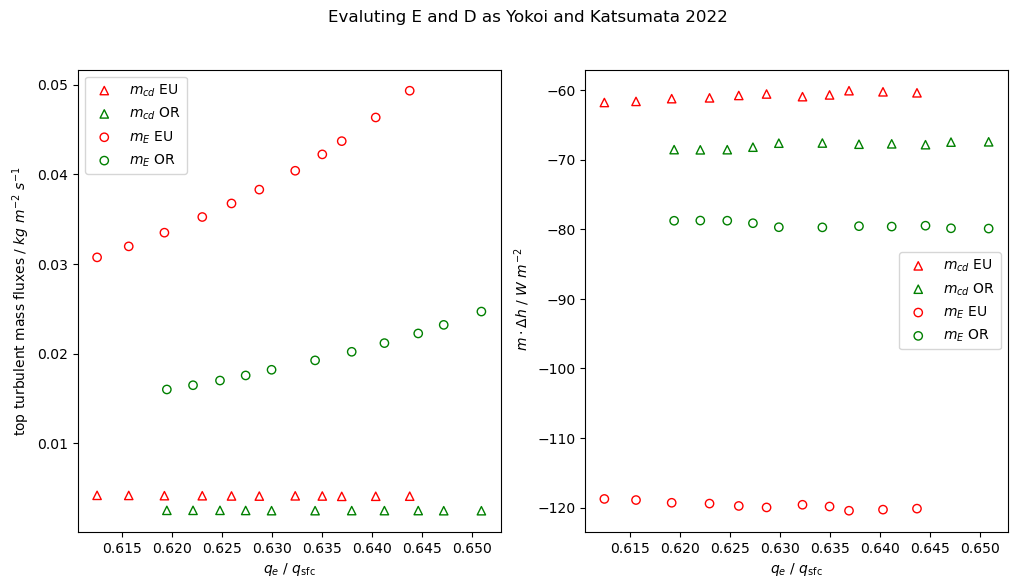

In [60]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
fig.suptitle("Evaluting E and D as Yokoi and Katsumata 2022")

#### report E for values of q_out
ax[0].scatter(q_out_eu*1e3/q_sfc_eu, mD_eu, marker="^", facecolors='none', edgecolors="red", label=r"$m_{cd}$ EU")
ax[0].scatter(q_out_or*1e3/q_sfc_or, mD_or, marker="^", facecolors='none', edgecolors="green", label=r"$m_{cd}$ OR")

ax[0].scatter(q_out_eu*1e3/q_sfc_eu, me_eu, marker="o", facecolors='none', edgecolors="red", label=r"$m_{E}$ EU")
ax[0].scatter(q_out_or*1e3/q_sfc_or, me_or, marker="o", facecolors='none', edgecolors="green", label=r"$m_{E}$ OR")

ax[0].set_xlabel(r"$q_e$ / $q_\mathrm{sfc}$")
ax[0].set_ylabel(r"top turbulent mass fluxes / $kg~m^{-2}~s^{-1}$")
ax[0].legend()




#### report E for values of q_out
ax[1].scatter(q_out_eu*1e3/q_sfc_eu, mD_eu*(  cp*(np.nanmean(thetaD_eu) - theta_bl_eu.values) + Lv*(np.nanmean(qSat_out_eu) - q_bl_eu.values)  ), marker="^", facecolors='none', edgecolors="red", label=r"$m_{cd}$ EU")
ax[1].scatter(q_out_or*1e3/q_sfc_or, mD_or*(  cp*(np.nanmean(thetaD_or) - theta_bl_or.values) + Lv*(np.nanmean(qSat_out_or) - q_bl_or.values)  ), marker="^", facecolors='none', edgecolors="green", label=r"$m_{cd}$ OR")

ax[1].scatter(q_out_eu*1e3/q_sfc_eu, me_eu*( cp*(theta_out_eu - theta_bl_eu.values) + Lv*(q_out_eu - q_bl_eu.values) ) , marker="o", facecolors='none', edgecolors="red", label=r"$m_{E}$ EU")
ax[1].scatter(q_out_or*1e3/q_sfc_or, me_or*( cp*(theta_out_or - theta_bl_or.values) + Lv*(q_out_or - q_bl_or.values) ), marker="o", facecolors='none', edgecolors="green", label=r"$m_{E}$ OR")

ax[1].set_xlabel(r"$q_e$ / $q_\mathrm{sfc}$")
ax[1].set_ylabel(r" $m\cdot \Delta h$ / $W~m^{-2}$")
ax[1].legend()


In [62]:
import pandas as pd
from IPython.display import display, HTML

data = [
    ["LHF ERA5 (W/m²)", f"{lhf_era5_eu:.2f}", f"{lhf_era5_or:.2f}"],
    ["SHF ERA5 (W/m²)", f"{shf_era5_eu:.2f}", f"{shf_era5_or:.2f}"],
    ["R (W/m²)", f"{( non_thBL_terms_eu - ((2 - eps)/(1 - eps))*eps*stefan*(theta_bl_eu)**4 ):.2f}", f"{( non_thBL_terms_or - ((2 - eps)/(1 - eps))*eps*stefan*(theta_bl_or)**4 ):.2f}"],
    [r"q_e - q_{BL} (g/kg)", f"{1e3*(q_out_eu[0] - q_bl_eu):.2f}", f"{1e3*(q_out_or[0] - q_bl_or):.2f}"],
    [r"q_cd - q_{BL} (g/kg)", f"{1e3*(qSat_out_eu[0] - q_bl_eu):.2f}", f"{1e3*(qSat_out_or[0] - q_bl_or):.2f}"],
    [r"$\theta_e$ - $\theta_{BL}$ (K)", f"{(theta_out_eu[0] - theta_bl_eu):.2f}", f"{(theta_out_or[0] - theta_bl_or):.2f}"],
    [r"$\theta_{cd}$ - $\theta_{BL}$ (K)", f"{(np.nanmean(thetaD_eu) - theta_bl_eu):.2f}", f"{(np.nanmean(thetaD_or) - theta_bl_or):.2f}"],
    
]

# Create DataFrame
df = pd.DataFrame(data, columns=["Quantity","EU", "OR"])

display(HTML(df.to_html(index=False, table_id="summary-table")))

Quantity,EU,OR
LHF ERA5 (W/m²),171.35,134.73
SHF ERA5 (W/m²),12.37,15.08
R (W/m²),-3.16,-2.46
q_e - q_{BL} (g/kg),-1.15,-1.54
q_cd - q_{BL} (g/kg),-1.31,-5.52
$\theta_e$ - $\theta_{BL}$ (K),0.44,0.62
$\theta_{cd}$ - $\theta_{BL}$ (K),-7.60,-11.32


In [42]:
## see dependence also on choice of downdraft levels


## save resulting values, depending on height selected
me_eu, me_or = np.zeros((q_out_eu.size, qSat_out_eu.size)), np.zeros((q_out_eu.size, qSat_out_eu.size))
mD_eu, mD_or = np.zeros((q_out_or.size, qSat_out_or.size)), np.zeros((q_out_or.size, qSat_out_or.size))


##
 
for i in range(me_eu[:,0].size):
    for j in range(me_eu[0,:].size):
        A_eu = np.array([
            [
                theta_out_eu[i] - theta_bl_eu,  thetaD_eu[j] - theta_bl_eu
            ],
            [
                q_out_eu[i] - q_bl_eu,          qSat_out_eu[j] - q_bl_eu
            ]
        ])

        b_eu = np.array([
            - shf_era5_eu.values/cp - (non_thBL_terms_eu - ((2 - eps)/(1 - eps))*eps*stefan*(theta_bl_eu.values)**4)/cp ,
            - lhf_era5_eu.values / Lv
        ])

        x_eu = np.linalg.pinv(A_eu) @ b_eu

        me_eu[i,j] = x_eu[0]
        mD_eu[i,j] = x_eu[1]


for i in range(me_or[:,0].size):
    for j in range(me_or[0,:].size):
        A_or = np.array([
            [
                theta_out_or[i] - theta_bl_or,    thetaD_or[j] - theta_bl_or
            ],
            [
                q_out_or[i] - q_bl_or,            qSat_out_or[j] - q_bl_or
            ]
        ])

        b_or = np.array([
            - shf_era5_or.values/cp - ( non_thBL_terms_or - ((2 - eps)/(1 - eps))*eps*stefan*(theta_bl_or)**4 )/cp,
            - lhf_era5_or.values/Lv 
        ])

        x_or = np.linalg.pinv(A_or) @ b_or

        me_or[i,j] = x_or[0]
        mD_or[i,j] = x_or[1]

me_eu, me_or = np.array(me_eu), np.array(me_or)
mD_eu, mD_or = np.array(mD_eu), np.array(mD_or)


In [108]:
theta_out_eu.shape

(11,)

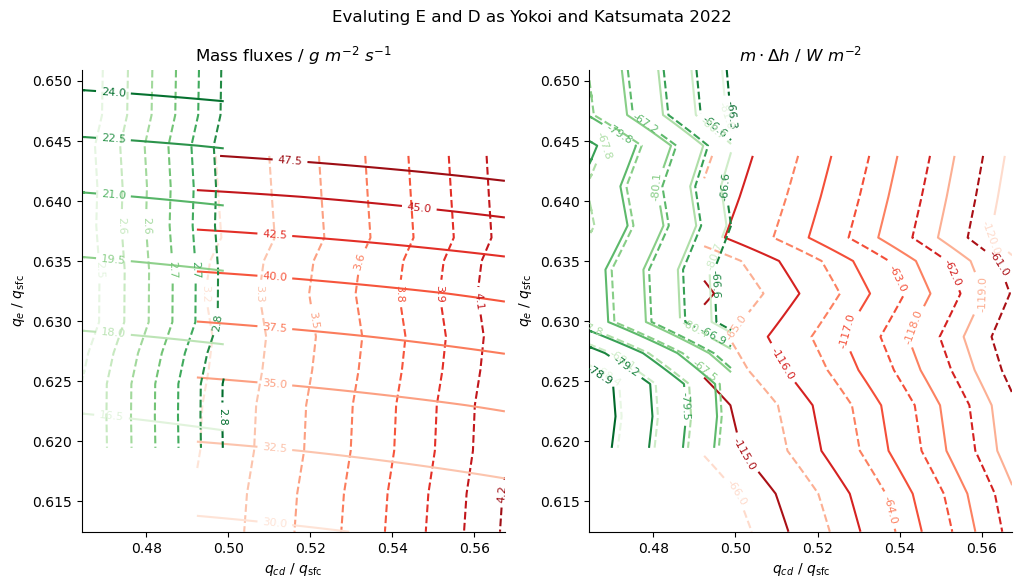

In [46]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
fig.suptitle("Evaluting E and D as Yokoi and Katsumata 2022")

#### report E for values of q_out

xx_eu, yy_eu = np.meshgrid(qSat_out_eu*1e3/q_sfc_eu, q_out_eu*1e3/q_sfc_eu)
xx_or, yy_or = np.meshgrid(qSat_out_or*1e3/q_sfc_or, q_out_or*1e3/q_sfc_or)

c1 = ax[0].contour(xx_eu, yy_eu, mD_eu*1e3, cmap="Reds", linestyles="--")   # , marker="^", facecolors='none', edgecolors="red", label=r"$m_{cd}$ EU")
c2 = ax[0].contour(xx_eu, yy_eu, me_eu*1e3, cmap="Reds")  # , marker="o", facecolors='none', edgecolors="red", label=r"$m_{E}$ EU")

c3 = ax[0].contour(xx_or, yy_or, mD_or*1e3, cmap="Greens", linestyles="--")   # , marker="^", facecolors='none', edgecolors="red", label=r"$m_{cd}$ EU")
c4 = ax[0].contour(xx_or, yy_or, me_or*1e3, cmap="Greens") 

ax[0].set_xlabel(r"$q_{cd}$ / $q_\mathrm{sfc}$")
ax[0].set_ylabel(r"$q_{e}$ / $q_\mathrm{sfc}$")
ax[0].set_title(r"Mass fluxes / $g~m^{-2}~s^{-1}$")
# ax[0].legend()

for c in [c1, c2, c3, c4]:
    plt.clabel(c, inline=True, fontsize=8, fmt='%.1f')


c1 = ax[1].contour(xx_eu, yy_eu, mD_eu*(  cp*(thetaD_eu[np.newaxis, :] - theta_bl_eu.values)    + Lv*(qSat_out_eu[np.newaxis, :] - q_bl_eu.values) ), cmap="Reds", linestyles="--" )
c2 = ax[1].contour(xx_eu, yy_eu, me_eu*(  cp*(theta_out_eu[:, np.newaxis] - theta_bl_eu.values) + Lv*(q_out_eu[:, np.newaxis] - q_bl_eu.values) ), cmap="Reds"   ) 

c3 = ax[1].contour(xx_or, yy_or, mD_or*(  cp*(thetaD_or[np.newaxis, :] - theta_bl_or.values)    + Lv*(qSat_out_or[np.newaxis, :] - q_bl_or.values) ), cmap="Greens", linestyles="--" )
c4 = ax[1].contour(xx_or, yy_or, me_or*(  cp*(theta_out_or[:, np.newaxis] - theta_bl_or.values) + Lv*(q_out_or[:, np.newaxis] - q_bl_or.values) ), cmap="Greens"   ) 

for c in [c1, c2, c3, c4]:
    plt.clabel(c, inline=True, fontsize=8, fmt='%.1f')

ax[1].set_xlabel(r"$q_{cd}$ / $q_\mathrm{sfc}$")
ax[1].set_ylabel(r"$q_{e}$ / $q_\mathrm{sfc}$")
ax[1].set_title(r"$m\cdot \Delta h$ / $W~m^{-2}$")

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)



In [59]:
theta_bl_eu.values

array(298.38904, dtype=float32)

#### can we estimate what role advection plays, using differences between each single radiosounding?

In [ ]:

def local_adv(ds, max_hgt):
    heightss = slice(50, max_hgt)
    wspd  = ds.wspd.sel(height=heightss)
    wspd_pair_mean = (wspd + wspd.shift(launch_time=-1)) / 2
    wspd_pair_mean = wspd_pair_mean.isel(launch_time=slice(0, -1)).values

    moist = ds.q.sel(height=heightss)
    th    = ds.theta.sel(height=heightss)

    dt  = (ds.launch_time.diff(dim="launch_time") / np.timedelta64(1,"h"))
    dt = dt.rename("dt")  # give it a name

    dt_hgt = dt.expand_dims(height=wspd.height).transpose("launch_time", "height")

    ## it's actually harder than I was expecting
    ## THIS IS THE TOTAL CHANGE IN TIME
    moist_adv = -wspd_pair_mean*((moist.diff(dim="launch_time")))  / (wspd_pair_mean*dt_hgt)
    th_adv    = -wspd_pair_mean*((th.diff(dim="launch_time")) ) / (wspd_pair_mean*dt_hgt)

    return moist_adv, th_adv




q_adv_eu, th_adv_eu = local_adv(ds_eureca_bco, max_hgt=500)
q_adv_or, th_adv_or = local_adv(ds_orcestra_bco, max_hgt=500)

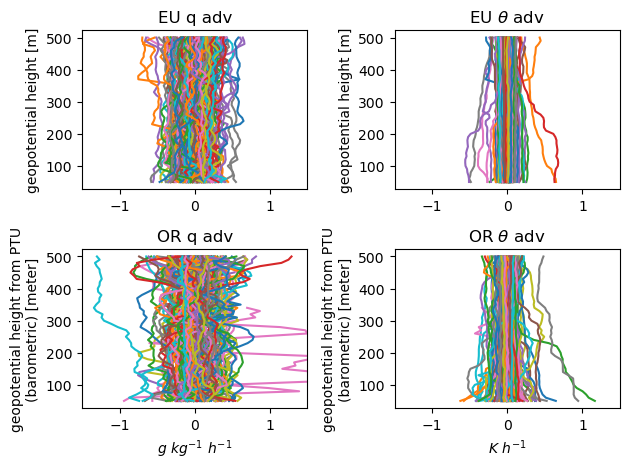

In [49]:
fig, ax = plt.subplots(2,2)
ax = ax.flatten()

(q_adv_eu*1e3).plot.line(ax=ax[0], y="height", add_legend=False)
(q_adv_or*1e3).plot.line(ax=ax[2], y="height", add_legend=False)

ax[0].set_title("EU q adv")
ax[0].set_xlabel("")
ax[2].set_title("OR q adv")
ax[2].set_xlabel(r"$g~kg^{-1}~h^{-1}$")

for x in [ax[0], ax[2]]:
    x.set_xlim(-1.5, 1.5)




th_adv_eu.plot.line(ax=ax[1], y="height", add_legend=False)
th_adv_or.plot.line(ax=ax[3], y="height", add_legend=False)

ax[1].set_title(r"EU $\theta$ adv")
ax[3].set_title(r"OR $\theta$ adv")
ax[1].set_xlabel("")
ax[3].set_xlabel(r"$K~h^{-1}$")

for x in [ax[1], ax[3]]:
    x.set_xlim(-1.5, 1.5)

plt.tight_layout()
plt.show()